# 9. Practical Training Challenges
---

In traditional machine learning, once you pick a model (say, a Random Forest or Gradient Boosting), it usually just works out of the box. You tune a few hyperparameters, cross-validate, and you're done.

**Neural networks are different.** They have far more things that can go wrong during training — and most of them are invisible unless you know what to look for. This notebook covers the most important practical problems you will encounter and exactly how to fix them.

Think of training a neural network like tuning a very complex engine. Each section below is one thing that can cause the engine to stall, run rough, or blow up — and the tools to fix it.

### What we cover:
| Section | Problem | Traditional ML Equivalent |
|---|---|---|
| 9.0 / 9.1 | Vanishing & exploding gradients | No direct equivalent — unique to deep networks |
| 9.2 | Weight initialisation | Feature scaling / normalisation |
| 9.3 | Batch normalisation | StandardScaler between layers |
| 9.4 | Overfitting (Dropout + L2) | L1/L2 regularisation, max_features in RF |
| 9.5 | **Architecture search** | **Optuna / GridSearchCV for hyperparameters** |
| 9.6 | Learning rate scheduling | No direct equivalent |
| 9.7 | Early stopping & checkpointing | Early stopping in XGBoost / sklearn |

## Setup

In [1]:
try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "torch", "torchvision", "--break-system-packages", "-q"])
    import torch

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
print("All imports OK")

PyTorch version: 2.11.0
All imports OK


---
## 9.0 The Vanishing Gradient Problem

### The intuition

Imagine a game of telephone where a message is whispered from person to person along a line of 20 people. By the time it reaches person 20, the original message has been distorted beyond recognition. The vanishing gradient problem is the mathematical equivalent of this happening to the error signal during backpropagation.

During backprop, the gradient of the loss travels **backwards** through every layer, being multiplied at each step by the derivative of that layer's activation function. The Sigmoid function's derivative has a maximum value of **0.25**. This means every time the signal passes through a Sigmoid layer, it shrinks to at most a quarter of its size.

Stack 10 layers and the gradient reaching the earliest layer is at most:
$$0.25^{10} = 0.000001$$

That layer receives essentially zero information about how to improve. **It stops learning entirely.** This is why early deep networks (pre-2012) failed — they used Sigmoid throughout, and the early layers simply never trained.

### The fix: ReLU

ReLU (Rectified Linear Unit) has a derivative of exactly **1** for any positive input. When the gradient passes through a ReLU layer where the neuron was active, it is not shrunk at all — it passes through at full strength. This one simple change is largely why deep learning became practical after 2012.

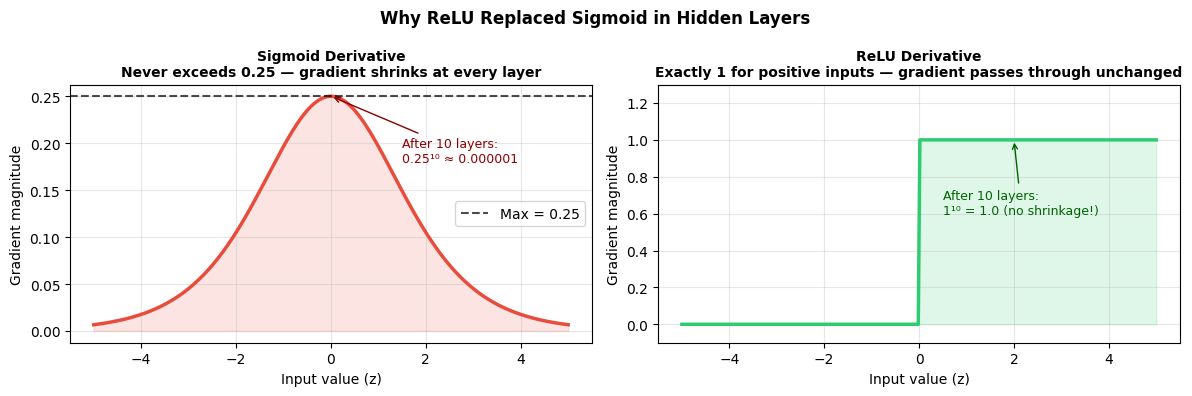

In [2]:
def sigmoid(x): 
    return 1 / (1 + np.exp(-x))
def relu(x):    
    return np.maximum(0, x)
def sigmoid_derivative(x): 
    return sigmoid(x) * (1 - sigmoid(x))
def relu_derivative(x):    
    return (x > 0).astype(float)

x_range = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Sigmoid derivative ---
axes[0].plot(x_range, sigmoid_derivative(x_range), color='#E74C3C', lw=2.5)
axes[0].axhline(0.25, color='black', linestyle='--', alpha=0.7, label='Max = 0.25')
axes[0].fill_between(x_range, sigmoid_derivative(x_range), alpha=0.15, color='#E74C3C')
axes[0].set_title("Sigmoid Derivative\nNever exceeds 0.25 — gradient shrinks at every layer",
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel("Input value (z)"); axes[0].set_ylabel("Gradient magnitude")
axes[0].annotate('After 10 layers:\n0.25¹⁰ ≈ 0.000001', xy=(0, 0.25), xytext=(1.5, 0.18),
                 fontsize=9, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred'))
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- ReLU derivative ---
axes[1].plot(x_range, relu_derivative(x_range), color='#2ECC71', lw=2.5)
axes[1].fill_between(x_range, relu_derivative(x_range), alpha=0.15, color='#2ECC71')
axes[1].set_title("ReLU Derivative\nExactly 1 for positive inputs — gradient passes through unchanged",
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel("Input value (z)"); axes[1].set_ylabel("Gradient magnitude")
axes[1].annotate('After 10 layers:\n1¹⁰ = 1.0 (no shrinkage!)', xy=(2, 1), xytext=(0.5, 0.6),
                 fontsize=9, color='darkgreen',
                 arrowprops=dict(arrowstyle='->', color='darkgreen'))
axes[1].set_ylim(-0.1, 1.3); axes[1].grid(alpha=0.3)

plt.suptitle("Why ReLU Replaced Sigmoid in Hidden Layers",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 9.1 Vanishing & Exploding Gradients — Measured in a Real Network

### Two failure modes, one cause

The same multiplication chain that causes vanishing gradients can also cause **exploding gradients** — where the gradient grows exponentially large instead of shrinking. This happens when the multiplied values are consistently greater than 1.

Think of it like compound interest:
- Multiplying by 0.25 each layer → money disappears (vanishing)
- Multiplying by 2.0 each layer → money becomes infinite (exploding)

Both are catastrophic. Vanishing means early layers learn nothing. Exploding means weights become `NaN` and training completely breaks.

### Where you see this most
- **Very deep networks** (20+ layers)
- **Recurrent networks (RNNs)** — the same weights are applied hundreds of times across a sequence, so even a small deviation from 1.0 compounds badly
- **Any network using Sigmoid or Tanh in hidden layers**

### The four fixes

| Fix | What it does | When to use |
|---|---|---|
| ReLU activation | Derivative = 1 for active neurons | Always, for hidden layers |
| He / Xavier initialisation | Weights start at the right scale | Always |
| Batch Normalisation | Re-centres activations each layer | Deep networks |
| Gradient clipping | Caps gradient norm before the update | RNNs, Transformers |

The code below actually measures gradient norms flowing back through a 20-layer network — you can see the difference directly.

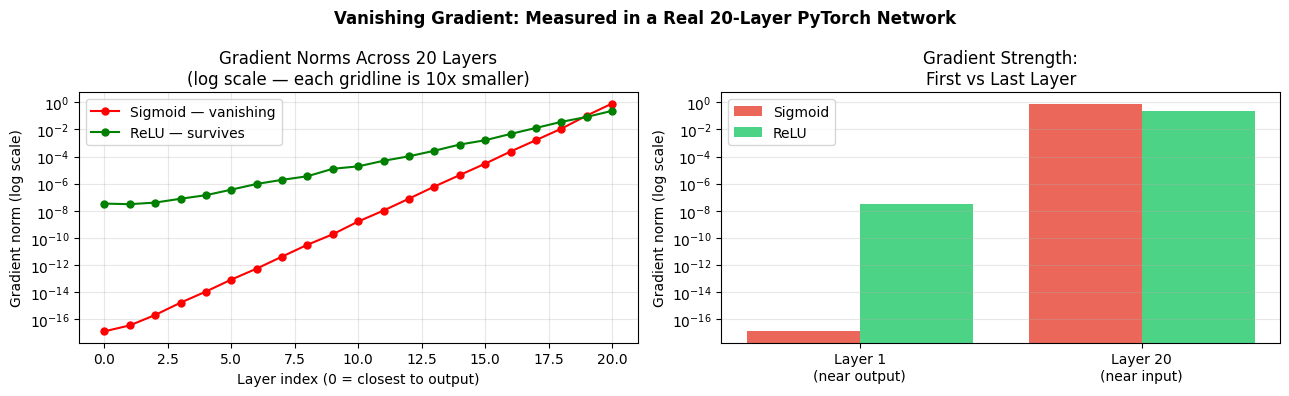

Sigmoid: gradient at layer 1 = 1.28e-17, at layer 20 = 8.22e-01
  → Shrunk by factor: 0x
ReLU:    gradient at layer 1 = 3.40e-08, at layer 20 = 2.39e-01


In [3]:
torch.manual_seed(42)

def make_deep_net(activation, n_layers=20, width=32):
    layers = [nn.Flatten(), nn.Linear(width, width), activation()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(width, width), activation()]
    layers.append(nn.Linear(width, 1))
    return nn.Sequential(*layers)

net_sigmoid = make_deep_net(nn.Sigmoid)
net_relu    = make_deep_net(nn.ReLU)

X_dummy   = torch.randn(16, 32)
y_dummy   = torch.randn(16, 1)
criterion = nn.MSELoss()

def get_grad_norms(model):
    """Run one forward+backward pass and collect the gradient norm at each Linear layer."""
    model.zero_grad()
    loss = criterion(model(X_dummy), y_dummy)
    loss.backward()
    norms = []
    for m in model.modules():
        if isinstance(m, nn.Linear) and m.weight.grad is not None:
            norms.append(m.weight.grad.norm().item())
    return norms

norms_sig  = get_grad_norms(net_sigmoid)
norms_relu = get_grad_norms(net_relu)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Line plot
axes[0].plot(norms_sig,  'r-o', markersize=5, label='Sigmoid — vanishing')
axes[0].plot(norms_relu, 'g-o', markersize=5, label='ReLU — survives')
axes[0].set_yscale('log')
axes[0].set_xlabel('Layer index (0 = closest to output)')
axes[0].set_ylabel('Gradient norm (log scale)')
axes[0].set_title('Gradient Norms Across 20 Layers\n(log scale — each gridline is 10x smaller)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Bar chart showing just first vs last layer
categories = ['Layer 1\n(near output)', 'Layer 20\n(near input)']
sig_vals  = [norms_sig[0],  norms_sig[-1]]
relu_vals = [norms_relu[0], norms_relu[-1]]
x = np.arange(2)
axes[1].bar(x - 0.2, sig_vals,  0.4, label='Sigmoid', color='#E74C3C', alpha=0.85)
axes[1].bar(x + 0.2, relu_vals, 0.4, label='ReLU',    color='#2ECC71', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xticks(x); axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Gradient norm (log scale)')
axes[1].set_title('Gradient Strength:\nFirst vs Last Layer')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Vanishing Gradient: Measured in a Real 20-Layer PyTorch Network',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Sigmoid: gradient at layer 1 = {norms_sig[0]:.2e}, at layer 20 = {norms_sig[-1]:.2e}")
print(f"  → Shrunk by factor: {norms_sig[0]/max(norms_sig[-1],1e-12):.0f}x")
print(f"ReLU:    gradient at layer 1 = {norms_relu[0]:.2e}, at layer 20 = {norms_relu[-1]:.2e}")

---
## 9.2 Weight Initialisation

### Why starting values matter so much

In neural networks, the starting weights have an outsized effect on whether training converges at all.

The fundamental problem is the signal passing through the network. At the start of training, the network is just random linear transformations stacked on top of each other. If the weights are too small, the signal (the data) gets multiplied by tiny numbers at each layer and shrinks to near zero by the output — the network can't distinguish any inputs from each other. If the weights are too large, the signal explodes and the activations saturate (all neurons output 1 or 0), producing zero gradients.

**The goal of weight initialisation is to keep the variance of activations roughly constant across all layers.** If activations have similar spread at every layer, gradients also have similar strength at every layer, and training works properly from the start.

### The two main schemes

**Xavier (Glorot) initialisation** — designed for Sigmoid and Tanh:
$$W \sim \mathcal{N}\left(0,\ \frac{1}{n_{\text{in}}}\right)$$
The variance is scaled by the number of inputs to the layer. More inputs → smaller weights, to keep the sum from blowing up.

**He (Kaiming) initialisation** — designed for ReLU:
$$W \sim \mathcal{N}\left(0,\ \frac{2}{n_{\text{in}}}\right)$$
The factor of 2 compensates for the fact that ReLU kills half its inputs (the negative half), effectively halving the variance. Without this compensation, the signal would still shrink.

### Analogy to traditional ML
Weight initialisation in deep learning plays a similar role to **feature scaling** (StandardScaler, MinMaxScaler) in traditional ML. Both ensure that inputs arrive at the learning algorithm in a well-conditioned numerical range so that gradient descent behaves predictably. The difference is that deep learning needs this conditioning *at every layer*, not just at the input.

### The good news
PyTorch's `nn.Linear` already uses He initialisation by default. You almost never need to set this manually unless you are doing something unusual.

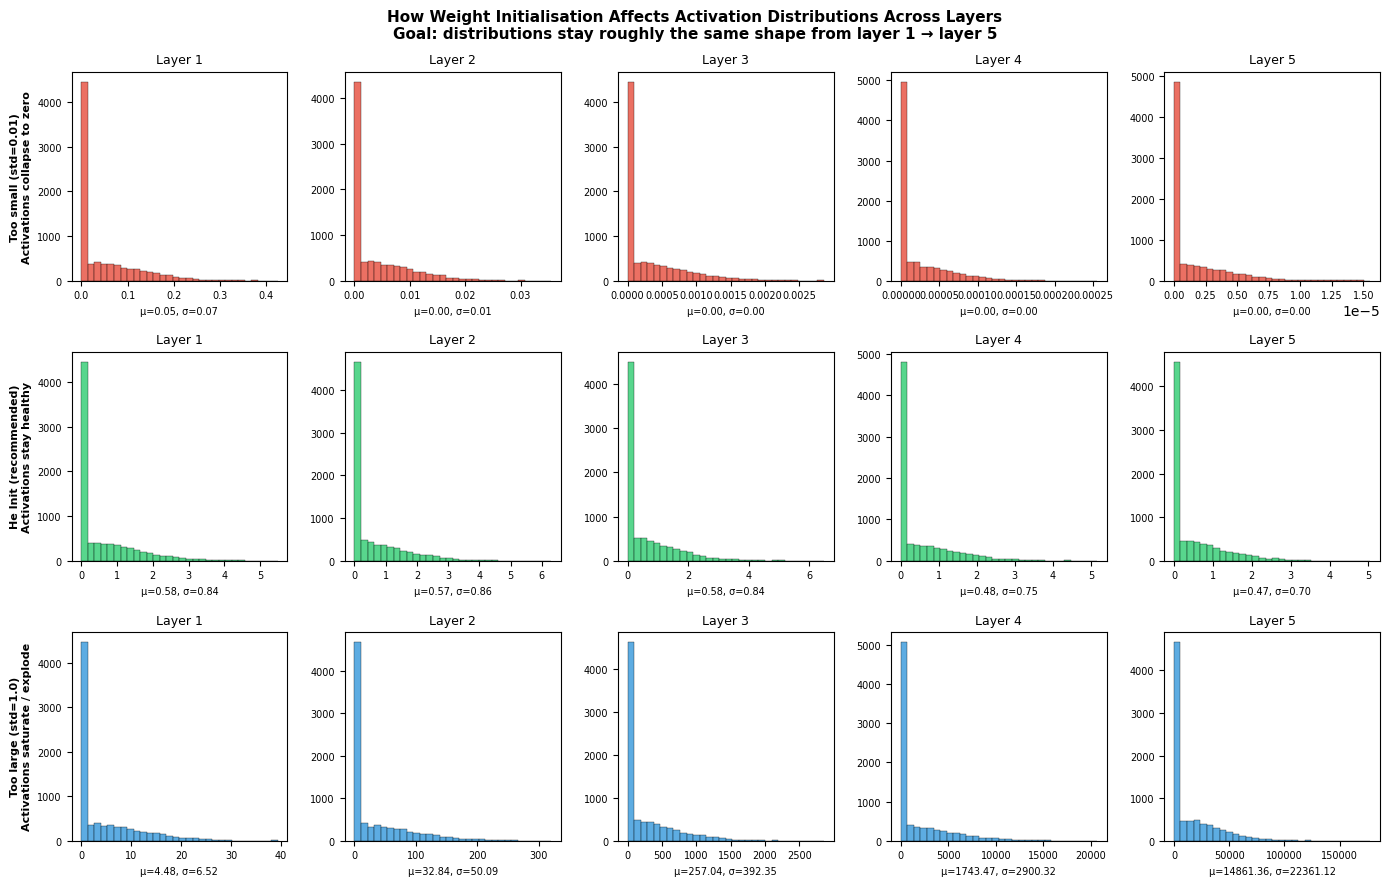


Key takeaway:
  Too small → all activations collapse to ~0 by layer 3. Network is blind.
  He Init   → distributions stay consistent. Each layer has useful signal.
  Too large → activations explode. Gradients become NaN.

PyTorch default: nn.Linear uses He init automatically.


In [4]:
torch.manual_seed(0)

def make_net_with_init(init_fn, n_layers=5, width=128):
    layers = []
    for _ in range(n_layers):
        layer = nn.Linear(128, width)
        init_fn(layer.weight)
        nn.init.zeros_(layer.bias)
        layers += [layer, nn.ReLU()]
    return nn.Sequential(*layers)

init_schemes = [
    ("Too small (std=0.01)\nActivations collapse to zero",    lambda w: nn.init.normal_(w, 0, 0.01)),
    ("He Init (recommended)\nActivations stay healthy",       lambda w: nn.init.kaiming_normal_(w)),
    ("Too large (std=1.0)\nActivations saturate / explode",   lambda w: nn.init.normal_(w, 0, 1.0)),
]

x_pt   = torch.randn(64, 128)
colors = ['#E74C3C', '#2ECC71', '#3498DB']

fig, axes = plt.subplots(3, 5, figsize=(14, 9))

for row, (name, init_fn) in enumerate(init_schemes):
    net = make_net_with_init(init_fn)
    activations = []

    def hook(module, inp, out):
        activations.append(out.detach().numpy().flatten())

    for layer in net:
        if isinstance(layer, nn.ReLU):
            layer.register_forward_hook(hook)

    with torch.no_grad():
        net(x_pt)

    for col, act in enumerate(activations[:5]):
        ax = axes[row, col]
        ax.hist(act, bins=30, color=colors[row], alpha=0.8, edgecolor='k', lw=0.3)
        ax.set_title(f"Layer {col+1}", fontsize=9)
        if col == 0:
            ax.set_ylabel(name, fontsize=8, fontweight='bold')
        mean_val = act.mean()
        std_val  = act.std()
        ax.set_xlabel(f"μ={mean_val:.2f}, σ={std_val:.2f}", fontsize=7)
        ax.tick_params(labelsize=7)

plt.suptitle(
    "How Weight Initialisation Affects Activation Distributions Across Layers\n"
    "Goal: distributions stay roughly the same shape from layer 1 → layer 5",
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nKey takeaway:")
print("  Too small → all activations collapse to ~0 by layer 3. Network is blind.")
print("  He Init   → distributions stay consistent. Each layer has useful signal.")
print("  Too large → activations explode. Gradients become NaN.")
print("\nPyTorch default: nn.Linear uses He init automatically.")

---
## 9.3 Batch Normalisation

### The problem it solves

Even with good weight initialisation, as training progresses the distribution of activations at each layer keeps shifting. The weights in layer 3 were tuned assuming layer 2 produces activations with a certain distribution — but as layer 2's weights update, that distribution changes. Layer 3 then has to constantly re-adapt to a moving target. This is called **internal covariate shift**.

An analogy from traditional ML: imagine you standardise your input features with StandardScaler before passing them to logistic regression. This works great. But now imagine every batch of data has a randomly different mean and variance — your StandardScaler would be useless because it was fit on one distribution but applied to another. Batch normalisation solves this problem inside the network by standardising the activations at each layer, for every batch, during training.

### What it does mathematically

For each feature in a mini-batch, BatchNorm computes the batch mean and variance and normalises:
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

Then it applies two **learnable** parameters γ (scale) and β (shift):
$$y_i = \gamma \hat{x}_i + \beta$$

The learnable parameters are important — they allow the network to undo the normalisation if that's what the data requires. BatchNorm does not force the activations to always be standard normal; it gives the network the *choice* to normalise or not.

### Training vs Inference

During **training**: normalisation uses statistics from the current mini-batch. This introduces a small amount of noise (different batches have slightly different statistics) which acts as a mild regulariser.

During **inference**: you don't have a batch — you might be predicting one sample at a time. BatchNorm uses **running averages** of the mean and variance that were accumulated during training. This is why you must call `model.eval()` before making predictions — it switches BatchNorm from batch-statistics mode to running-statistics mode.

### Benefits summary
- Stabilises training, especially with large learning rates
- Reduces dependence on careful weight initialisation
- Acts as a mild regulariser (can reduce the need for Dropout)
- Allows training much deeper networks reliably

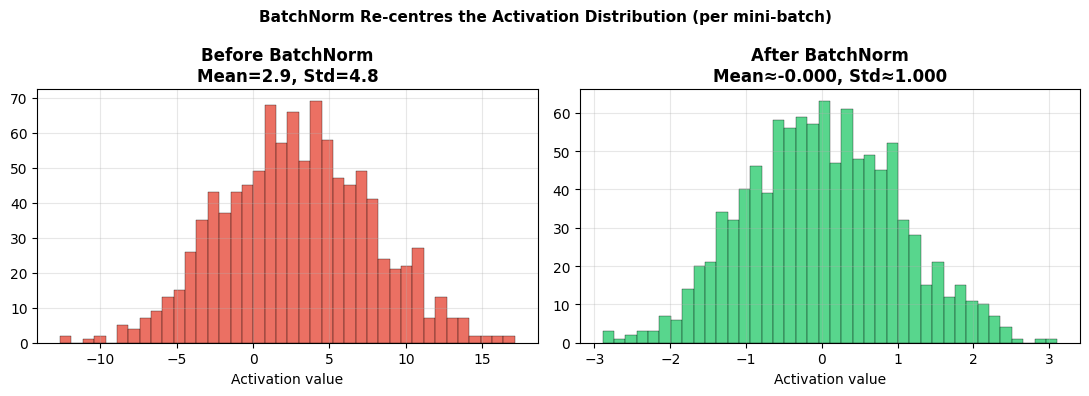

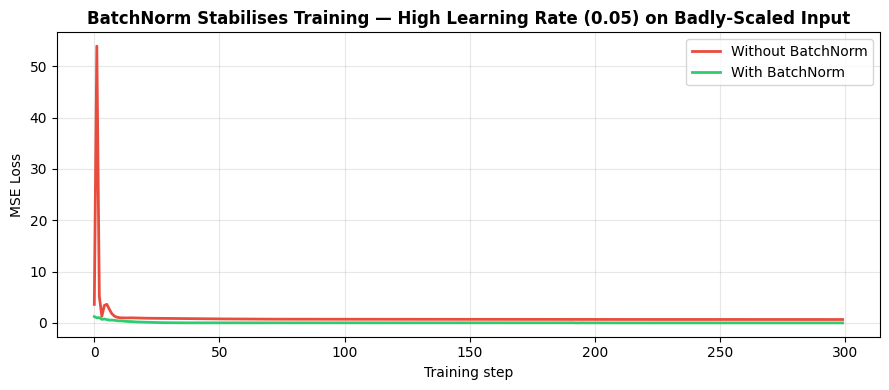

In [5]:
torch.manual_seed(1)

# Show what BatchNorm does to a badly-scaled input
batch_pt      = torch.tensor(np.random.randn(64, 16) * 5 + 3, dtype=torch.float32)
bn_layer      = nn.BatchNorm1d(num_features=16)
bn_layer.train()
normalised_pt = bn_layer(batch_pt)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(batch_pt.numpy().flatten(), bins=40, color='#E74C3C', alpha=0.8, edgecolor='k', lw=0.3)
axes[0].set_title(f"Before BatchNorm\nMean={batch_pt.mean():.1f}, Std={batch_pt.std():.1f}",
                  fontweight='bold')
axes[0].set_xlabel("Activation value"); axes[0].grid(alpha=0.3)

axes[1].hist(normalised_pt.detach().numpy().flatten(), bins=40, color='#2ECC71',
             alpha=0.8, edgecolor='k', lw=0.3)
axes[1].set_title(
    f"After BatchNorm\nMean≈{normalised_pt.mean().item():.3f}, Std≈{normalised_pt.std().item():.3f}",
    fontweight='bold')
axes[1].set_xlabel("Activation value"); axes[1].grid(alpha=0.3)

plt.suptitle("BatchNorm Re-centres the Activation Distribution (per mini-batch)",
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Now show training stability benefit
model_bn    = nn.Sequential(nn.Linear(16,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64,1))
model_no_bn = nn.Sequential(nn.Linear(16,64),                    nn.ReLU(), nn.Linear(64,1))

opt_bn    = torch.optim.Adam(model_bn.parameters(),    lr=0.05)  # deliberately high lr
opt_no_bn = torch.optim.Adam(model_no_bn.parameters(), lr=0.05)
crit      = nn.MSELoss()

X_bn = torch.randn(128, 16) * 5 + 3
y_bn = torch.randn(128, 1)

losses_bn, losses_no_bn = [], []
for _ in range(300):
    for model, opt, store in [(model_bn, opt_bn, losses_bn),
                               (model_no_bn, opt_no_bn, losses_no_bn)]:
        model.train()
        opt.zero_grad()
        loss = crit(model(X_bn), y_bn)
        loss.backward()
        opt.step()
        store.append(loss.item())

plt.figure(figsize=(9, 4))
plt.plot(losses_no_bn, color='#E74C3C', lw=2, label='Without BatchNorm')
plt.plot(losses_bn,    color='#2ECC71', lw=2, label='With BatchNorm')
plt.title("BatchNorm Stabilises Training — High Learning Rate (0.05) on Badly-Scaled Input",
          fontweight='bold')
plt.xlabel("Training step"); plt.ylabel("MSE Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Where to place BatchNorm in the network?**

The conventional placement is after the linear layer and before the activation:
```
Linear → BatchNorm → ReLU → Dropout
```
Some modern architectures place it after the activation. In practice, before tends to work slightly better for dense networks. The most important thing is to be consistent.

---
## 9.4 Overfitting: Dropout & L2 Regularisation

### Overfitting — the same problem, amplified

Overfitting in neural networks is the same concept as in traditional ML: the model memorises the training data rather than learning the underlying patterns. In a Random Forest you control overfitting with `max_depth` and `min_samples_leaf`. In logistic regression you use C (the inverse of the L2 strength). Neural networks have their own toolkit.

Neural networks are particularly prone to overfitting because they have so many parameters — a simple two-layer network on MNIST has over 100,000 weights. Given enough capacity, the network can simply memorise every training sample.

### Fix 1: Dropout

During training, Dropout randomly sets a fraction of neurons to zero for each forward pass. With `p=0.3`, 30% of neurons are silenced at each step — but a different random 30% each time.

Why does this help? It forces the network to never rely on any single neuron being present. Every neuron must learn features that are useful on their own, not just in combination with specific other neurons. The effect is similar to training an ensemble of many different smaller networks simultaneously — at test time, you use all the neurons together, which averages out the variance.

This connects to **bagging** in traditional ML (Random Forests use random feature subsets at each split for the same reason — to prevent any single feature from dominating).

**Important:** Dropout is turned OFF during inference (`model.eval()`). During test time all neurons are active, and the weights are implicitly scaled to compensate (PyTorch handles this automatically with inverted dropout).

### Fix 2: L2 Regularisation (Weight Decay)

This is identical in concept to L2 regularisation in logistic regression or Ridge regression. A penalty proportional to the sum of squared weights is added to the loss:
$$L_{\text{total}} = L_{\text{task}} + \lambda \sum_w w^2$$

Large weights are penalised, pushing the model toward simpler explanations. In PyTorch, you don't add this manually — you pass `weight_decay=λ` to the optimizer and it handles it:
```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
```

Typical values are between `1e-5` and `1e-3`. Too high and the model underfits; too low and it has no effect.

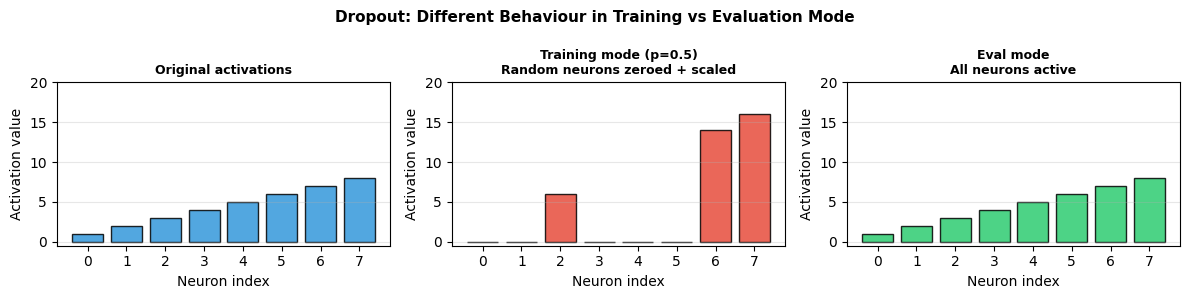

Note: surviving neurons are scaled up by 1/(1-p) = 2.0x to preserve expected activation magnitude


In [6]:
torch.manual_seed(0)

# --- Show Dropout behaviour ---
drop = nn.Dropout(p=0.5)
a    = torch.tensor([1., 2., 3., 4., 5., 6., 7., 8.])

drop.train()
a_train = drop(a)
drop.eval()
a_eval  = drop(a)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
bars = [a.numpy(), a_train.detach().numpy(), a_eval.detach().numpy()]
titles = ['Original activations', 'Training mode (p=0.5)\nRandom neurons zeroed + scaled', 
          'Eval mode\nAll neurons active']
colors = ['#3498DB', '#E74C3C', '#2ECC71']

for ax, vals, title, col in zip(axes, bars, titles, colors):
    ax.bar(range(len(vals)), vals, color=col, alpha=0.85, edgecolor='k')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Neuron index'); ax.set_ylabel('Activation value')
    ax.set_ylim(-0.5, 20); ax.grid(alpha=0.3, axis='y')
    ax.set_xticks(range(len(vals)))

plt.suptitle("Dropout: Different Behaviour in Training vs Evaluation Mode",
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Note: surviving neurons are scaled up by 1/(1-p) = {1/0.5:.1f}x to preserve expected activation magnitude")

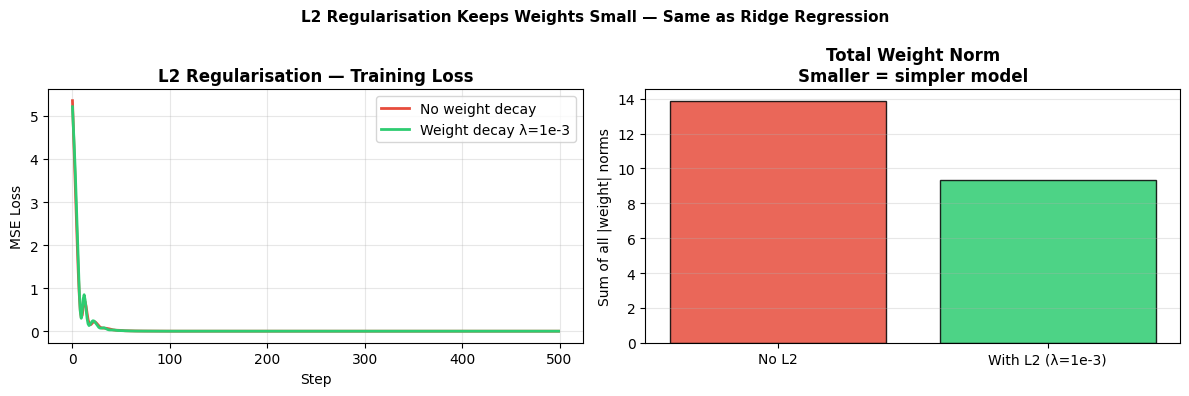

Weight norm without L2: 13.86
Weight norm with L2:    9.33  ← significantly smaller


In [7]:
torch.manual_seed(42)

# Noisy data — easy to overfit
X_reg = torch.randn(50, 8)
y_reg = X_reg[:, 0:1] * 2 + 0.5 * torch.randn(50, 1)  # only 1 of 8 features is real

def make_reg_model():
    return nn.Sequential(nn.Linear(8,64), nn.ReLU(),
                         nn.Linear(64,32), nn.ReLU(),
                         nn.Linear(32,1))

model_l2    = make_reg_model()
model_no_l2 = make_reg_model()

opt_l2    = torch.optim.Adam(model_l2.parameters(),    lr=0.01, weight_decay=1e-3)
opt_no_l2 = torch.optim.Adam(model_no_l2.parameters(), lr=0.01, weight_decay=0)

crit = nn.MSELoss()
losses_l2, losses_no = [], []

for _ in range(500):
    for model, opt, store in [(model_l2, opt_l2, losses_l2),
                               (model_no_l2, opt_no_l2, losses_no)]:
        opt.zero_grad()
        loss = crit(model(X_reg), y_reg)
        loss.backward()
        opt.step()
        store.append(loss.item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_no, color='#E74C3C', lw=2, label='No weight decay')
axes[0].plot(losses_l2, color='#2ECC71', lw=2, label='Weight decay λ=1e-3')
axes[0].set_title("L2 Regularisation — Training Loss", fontweight='bold')
axes[0].set_xlabel("Step"); axes[0].set_ylabel("MSE Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

no_l2_norm = sum(p.norm().item() for p in model_no_l2.parameters())
l2_norm    = sum(p.norm().item() for p in model_l2.parameters())
axes[1].bar(['No L2', 'With L2 (λ=1e-3)'], [no_l2_norm, l2_norm],
            color=['#E74C3C', '#2ECC71'], alpha=0.85, edgecolor='k')
axes[1].set_title("Total Weight Norm\nSmaller = simpler model", fontweight='bold')
axes[1].set_ylabel("Sum of all |weight| norms")
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle("L2 Regularisation Keeps Weights Small — Same as Ridge Regression",
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Weight norm without L2: {no_l2_norm:.2f}")
print(f"Weight norm with L2:    {l2_norm:.2f}  ← significantly smaller")

---
## 9.5 Architecture Search — How Wide? How Deep?

### The core question

When you build a neural network, you have to decide:
- How many layers? (depth)
- How many neurons per layer? (width)
- Which activation functions?
- How much dropout?
- What learning rate?

These are all **hyperparameters** — settings that are not learned during training, but chosen before training begins. In traditional ML, you know this problem well: you'd use **GridSearchCV** for small search spaces or **Optuna** for larger ones to find the best hyperparameters via cross-validation.

Deep learning has the exact same problem, just with more hyperparameters and much more expensive evaluations (each trial takes minutes to hours instead of seconds).

### Guiding principles before you search

Before running any automated search, use these rules of thumb to narrow down the space:

**Depth (number of layers):**
- Simple tabular data → 2–4 layers is almost always enough
- Images → 5–50 layers (or use a pretrained CNN)
- Text / sequences → 6–12 Transformer layers
- Adding more layers helps until you hit diminishing returns — the loss curve stops improving

**Width (neurons per layer):**
- Start with powers of 2: 64, 128, 256, 512
- A common pattern is a **funnel** — wider at the input, narrower toward the output
- Width should relate to the complexity of the input: 784 pixels → 256 → 128 → 10 makes sense; 5 features → 256 neurons is almost certainly overkill
- A useful heuristic: start with width ≈ 2–4× your input size

**General rule:** Start with the smallest network that you think could plausibly solve the problem. If it underfits (train loss stays high), make it bigger. If it overfits (train accuracy >> test accuracy), add regularisation rather than making it smaller.

### Optuna for deep learning — yes, it works

**Optuna works exactly the same way for deep learning as for traditional ML.** You define a search space of hyperparameters, Optuna proposes trials, you train the network for each trial and report the validation metric, and Optuna uses Bayesian optimisation to focus on promising regions of the search space.

The only difference is that each trial is far more expensive, so you typically:
1. Use fewer epochs per trial (enough to see if it's promising)
2. Use **pruning** — Optuna can kill unpromising trials early
3. Run trials in parallel if you have multiple GPUs

### Architecture search — practical advice

| Approach | When to use | Cost |
|---|---|---|
| Manual rules of thumb | Always start here | Free |
| Optuna (as above) | Tabular data, smaller models | Low–Medium |
| Ray Tune | Large models, multi-GPU | Medium–High |
| Neural Architecture Search (NAS) | Research / very large budgets | Very High |
| Pretrained + fine-tune | Images, text — almost always best | Low |

**The most important practical advice:** For image or text tasks, do not design your own architecture from scratch. Use a pretrained model (ResNet, EfficientNet, BERT, etc.) and fine-tune it on your data. This will almost always outperform a custom architecture trained from scratch, with a fraction of the compute.

---
## 9.6 Learning Rate Scheduling

### The problem with a fixed learning rate

The learning rate controls how large each weight update step is. Early in training, you want large steps — you're far from the solution and need to cover ground quickly. Late in training, large steps are destructive — you're close to a good solution and big steps cause you to overshoot and bounce around rather than settling in.

A fixed learning rate is a compromise that is rarely optimal at either phase. **Learning rate scheduling** automatically reduces the learning rate as training progresses, giving you the speed of a high rate early and the precision of a low rate late.

An analogy: when parallel parking, you approach the space quickly, then slow down for the fine adjustments. Nobody approaches at full speed and parks in one motion — you'd crash. A learning rate scheduler automates this slowdown.

### Common scheduler types

**StepLR** — reduce by a fixed factor every N epochs. Simple and predictable.

**ReduceLROnPlateau** — monitor the validation loss. If it hasn't improved for `patience` epochs, reduce the learning rate. This is the most practical scheduler because it responds to what's actually happening in training rather than following a fixed schedule.

**CosineAnnealingLR** — the learning rate follows a cosine curve from high to near-zero. Very popular in modern deep learning because the smooth decay tends to find better final solutions.

**OneCycleLR** — briefly increases the learning rate then decreases it. Used in fast training recipes.

The traditional ML equivalent is the `learning_rate` schedule in XGBoost — though there you typically just set a small constant rate. Neural network schedulers are more dynamic.

/var/folders/sr/rk5m4bnd15j7087y8pk1gn5m0000gp/T/ipykernel_48755/284948076.py:24: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


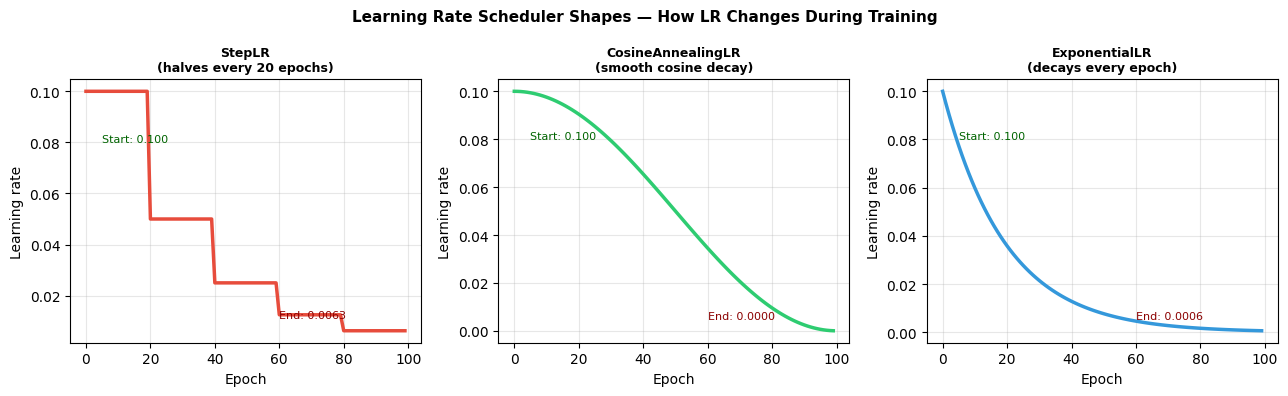

In [8]:
# Visualise the three main scheduler shapes — no training needed
import torch.optim.lr_scheduler as sched

n_epochs = 100
dummy_model = nn.Linear(1, 1)  # just need something with parameters

schedulers = [
    ('StepLR\n(halves every 20 epochs)',
     sched.StepLR(optim.SGD(dummy_model.parameters(), lr=0.1), step_size=20, gamma=0.5)),
    ('CosineAnnealingLR\n(smooth cosine decay)',
     sched.CosineAnnealingLR(optim.SGD(dummy_model.parameters(), lr=0.1), T_max=n_epochs)),
    ('ExponentialLR\n(decays every epoch)',
     sched.ExponentialLR(optim.SGD(dummy_model.parameters(), lr=0.1), gamma=0.95)),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#E74C3C', '#2ECC71', '#3498DB']

for ax, (name, scheduler), col in zip(axes, schedulers, colors):
    lrs = []
    opt = scheduler.optimizer
    for _ in range(n_epochs):
        lrs.append(opt.param_groups[0]['lr'])
        scheduler.step()
    ax.plot(lrs, color=col, lw=2.5)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate')
    ax.grid(alpha=0.3)
    ax.annotate(f"Start: {lrs[0]:.3f}", xy=(0, lrs[0]), xytext=(5, lrs[0]*0.8),
                fontsize=8, color='darkgreen')
    ax.annotate(f"End: {lrs[-1]:.4f}", xy=(n_epochs-1, lrs[-1]), xytext=(n_epochs*0.6, lrs[-1]+0.005),
                fontsize=8, color='darkred')

plt.suptitle('Learning Rate Scheduler Shapes — How LR Changes During Training',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

/Users/samson.afolabi/Documents/DSR/Deep_Learning_Notebooks/deep_learning_311/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  current = float(metrics)


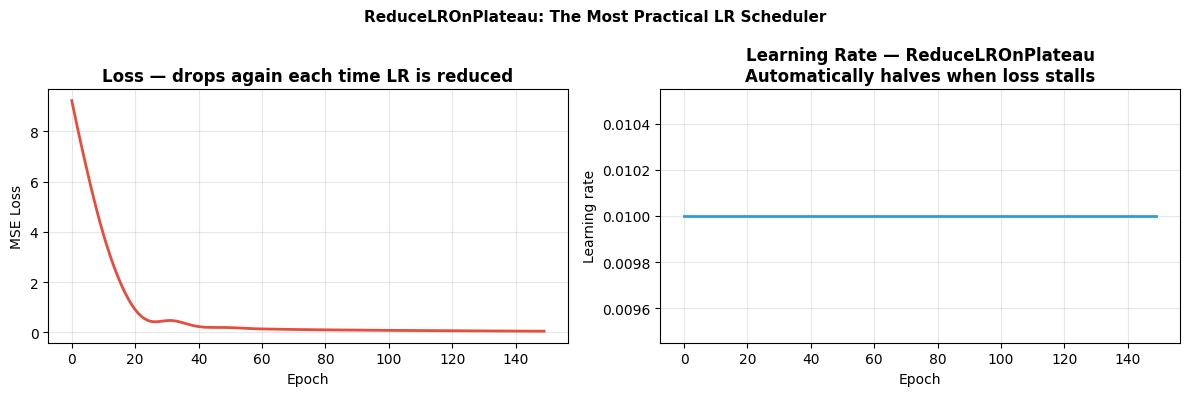

In [10]:
# ReduceLROnPlateau — the most practical scheduler
# It watches the validation loss and reduces LR automatically when progress stalls

torch.manual_seed(42)
X_s = torch.randn(200, 10)
y_s = X_s[:, 0:1] * 3 + 0.5 * torch.randn(200, 1)

model_sched = nn.Sequential(nn.Linear(10,64), nn.ReLU(), nn.Linear(64,1))
opt_sched   = optim.Adam(model_sched.parameters(), lr=0.01)
# patience=10 → wait 10 epochs of no improvement before reducing
# factor=0.5  → multiply LR by 0.5 when triggered
plateau_sched = optim.lr_scheduler.ReduceLROnPlateau(opt_sched, patience=10, factor=0.5)
crit = nn.MSELoss()

sched_losses, sched_lrs = [], []
for epoch in range(150):
    model_sched.train()
    opt_sched.zero_grad()
    loss = crit(model_sched(X_s), y_s)
    loss.backward()
    opt_sched.step()
    plateau_sched.step(loss)    # ← pass the loss; scheduler decides whether to reduce LR
    sched_losses.append(loss.item())
    sched_lrs.append(opt_sched.param_groups[0]['lr'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sched_losses, color='#E74C3C', lw=2)
axes[0].set_title('Loss — drops again each time LR is reduced', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(sched_lrs, color='#3498DB', lw=2)
axes[1].set_title('Learning Rate — ReduceLROnPlateau\nAutomatically halves when loss stalls',
                  fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Learning rate'); axes[1].grid(alpha=0.3)

plt.suptitle('ReduceLROnPlateau: The Most Practical LR Scheduler',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 9.7 Early Stopping & Checkpointing

### Early stopping

Early stopping in deep learning is identical in concept to early stopping in XGBoost or sklearn's `early_stopping_rounds`. You monitor the **validation loss** during training, and stop when it stops improving — even if the training loss is still decreasing. This prevents overfitting and saves compute.

The key parameter is **patience** — how many epochs without improvement before you stop. A patience of 10 means you will wait 10 consecutive epochs of no validation improvement before giving up.

### Checkpointing

Checkpointing means saving the model's weights to disk periodically during training. The standard pattern is to save the model every time the validation loss reaches a new best. This way, if the model later overfits or training crashes, you can reload the best version.

In traditional ML, sklearn models are small enough that you just fit and save at the end. Neural network training can take hours or days, so saving intermediate checkpoints is essential — you do not want to lose 12 hours of training because of a crash.

Early stopping triggered at epoch 65
Best validation loss: 0.1676 — restoring best weights


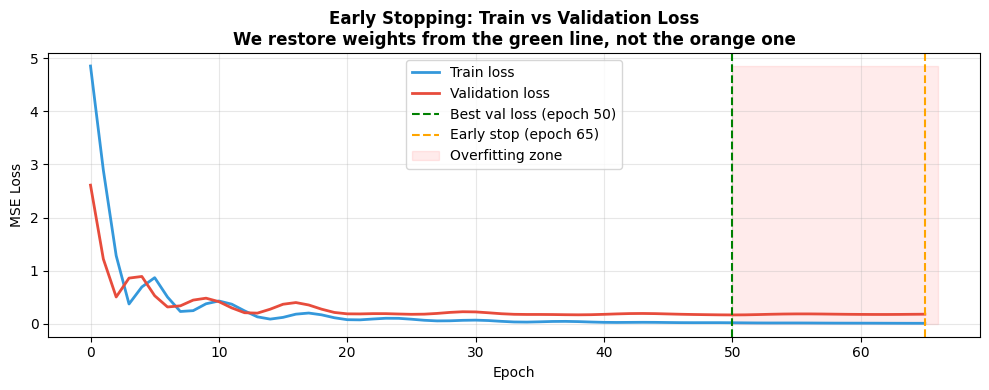


Full training would have run 200 epochs.
Early stopping saved 135 epochs of unnecessary compute.
And protected against overfitting by restoring epoch 50 weights.


In [11]:
import copy

torch.manual_seed(7)

# Synthetic data
X_es     = torch.randn(300, 10)
y_es     = X_es[:, 0:1] * 2 + 0.3 * torch.randn(300, 1)
X_tr, X_vl = X_es[:200], X_es[200:]
y_tr, y_vl = y_es[:200], y_es[200:]

# Deliberately large model — will overfit
model_es = nn.Sequential(
    nn.Linear(10, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 1)
)
opt_es = optim.Adam(model_es.parameters(), lr=0.005)
crit   = nn.MSELoss()

# Early stopping state
patience      = 15
best_val_loss = float('inf')
epochs_no_improve = 0
best_weights  = None   # will store the best model weights
stopped_epoch = None

tr_losses, vl_losses = [], []

for epoch in range(200):
    # Training step
    model_es.train()
    opt_es.zero_grad()
    tr_loss = crit(model_es(X_tr), y_tr)
    tr_loss.backward()
    opt_es.step()

    # Validation step
    model_es.eval()
    with torch.no_grad():
        vl_loss = crit(model_es(X_vl), y_vl).item()

    tr_losses.append(tr_loss.item())
    vl_losses.append(vl_loss)

    # Checkpoint: save best weights
    if vl_loss < best_val_loss:
        best_val_loss     = vl_loss
        best_weights      = copy.deepcopy(model_es.state_dict())  # save weights
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Early stopping check
    if epochs_no_improve >= patience:
        stopped_epoch = epoch
        print(f"Early stopping triggered at epoch {epoch}")
        print(f"Best validation loss: {best_val_loss:.4f} — restoring best weights")
        break

# Restore best weights from checkpoint
model_es.load_state_dict(best_weights)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tr_losses, color='#3498DB', lw=2, label='Train loss')
ax.plot(vl_losses, color='#E74C3C', lw=2, label='Validation loss')

best_ep = vl_losses.index(min(vl_losses))
ax.axvline(best_ep, color='green', linestyle='--', lw=1.5,
           label=f'Best val loss (epoch {best_ep})')
if stopped_epoch:
    ax.axvline(stopped_epoch, color='orange', linestyle='--', lw=1.5,
               label=f'Early stop (epoch {stopped_epoch})')

ax.fill_betweenx([0, max(tr_losses+vl_losses)], best_ep, len(tr_losses),
                 alpha=0.08, color='red', label='Overfitting zone')

ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Early Stopping: Train vs Validation Loss\nWe restore weights from the green line, not the orange one',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nFull training would have run 200 epochs.")
print(f"Early stopping saved {200 - stopped_epoch if stopped_epoch else 0} epochs of unnecessary compute.")
print(f"And protected against overfitting by restoring epoch {best_ep} weights.")

---
## Summary — Practical Training Checklist

When your network is not training well, work through this checklist in order:

| Check | What to look for | Fix |
|---|---|---|
| Loss is `NaN` immediately | Exploding gradients | Gradient clipping, lower LR, He init |
| Loss barely moves | Vanishing gradients | Switch to ReLU, add BatchNorm |
| Loss moves but slowly | LR too small | Increase LR or use scheduler |
| Loss oscillates wildly | LR too large | Decrease LR |
| Train loss low, val loss high | Overfitting | Add Dropout, weight decay, more data |
| Both losses plateau high | Underfitting | Bigger network, more epochs |

The traditional ML mental model still applies: bias-variance tradeoff, regularisation, hyperparameter search, cross-validation. Deep learning adds new tools (BatchNorm, Dropout, scheduling, gradient clipping) but the underlying problems are the same ones you already know.